# PROJETO INTERDISCIPLINAR · SISA


## 1. Configuração do ambiente

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

## 2. Carregamento da base

A planilha utilizada no projeto possui as abas:

- `FINANCEIRA`
- `ACADEMICA`
- `RELACIONAMENTO`
- `GEOGRAFICA`
- `TODAS`

Para a baseline será utilizada principalmente a aba **TODAS**, pois ela consolida as diferentes dimensões do estudante.

In [7]:
# 2. CARREGAMENTO DA BASE
# ============================================================

arquivo_base = "/base_final_2.xlsx"

xls = pd.ExcelFile(arquivo_base)

print("Abas encontradas:")
print(xls.sheet_names)

df = pd.read_excel(
    arquivo_base,
    sheet_name="base_unificada_final"
)

print("\nDimensão da base:")
print(f"{df.shape[0]} registros e {df.shape[1]} colunas")

display(df.head())

Abas encontradas:
['base_unificada_final']

Dimensão da base:
12846 registros e 30 colunas


,ID_ALUNO,evadiu,Forma de Ingresso,Grau Acadêmico,Turno,periodo_ingresso_num,periodo_atual_num,tempo_de_curso,Idade,Estado Civil,Sexo,distancia_km,faixa_distancia,total_parcelas,pct_parcelas_em_aberto,pct_parcelas_acordo,atraso_medio_dias,antecipacao_media_dias,tem_bolsa,valor_total_periodo,media_notas,media_assiduidade,pct_reprovacao,mudanca_recente_notas,mudanca_recente_assiduidade,tendencia_notas,tendencia_assiduidade,total_semestres,total_contatos,dias_desde_ultimo_contato
0,5913,True,Matricula Inicial,Pós-Graduação,Noite,2020.0,2020.0,0.0,40,Nao informado,Feminino,14.54,10 à 30km,31.0,0.0,0.0,0.0,5.0,True,1904.94,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0,0,0
1,1887,False,Enem,Bacharelado,Manhã,2015.0,2020.0,10.0,35,Solteiro,Masculino,2026-02-15 00:00:00,10 à 30km,6.0,0.0,0.0,50.83,0.17,False,10796.0,90.62,98.57,0.0,0.0,0.0,0.0,0.0,1,0,0
2,1911,False,Matricula Inicial,Pós-Graduação,Noite,2020.0,2020.0,0.0,42,Nao informado,Masculino,199.66,mais de 30km,18.0,0.0,0.0,2.22,0.0,True,26982.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0,0,0
3,7819,False,Matricula Inicial,Pós-Graduação,Noite,2020.0,2020.0,0.0,34,Nao informado,Masculino,29.22,10 à 30km,19.0,0.0,0.0,4.16,0.0,True,28481.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0,0,0
4,11620,False,Transferência,Bacharelado,Manhã,2015.0,2020.0,10.0,32,Solteiro,Masculino,0.0,nao_informado,6.0,0.0,0.0,13.33,0.0,False,2159-02-01 00:00:00,72.5,100.00,0.0,0.0,0.0,0.0,0.0,1,1,17


## 3. Análise dos Dados

In [8]:
print("Quantidade de registros:", len(df))
print("Quantidade de colunas:", df.shape[1])
print("Quantidade de alunos distintos:", df["ID_ALUNO"].nunique())
print("Quantidade de IDs duplicados:", df["ID_ALUNO"].duplicated().sum())

print("\nDistribuição da variável-alvo:")
display(df["evadiu"].value_counts(dropna=False).to_frame("Quantidade"))

print("\nDistribuição percentual:")
display(
    (df["evadiu"].value_counts(normalize=True, dropna=False) * 100)
    .round(2)
    .to_frame("Percentual (%)")
)

Quantidade de registros: 12846
Quantidade de colunas: 30
Quantidade de alunos distintos: 12839
Quantidade de IDs duplicados: 7

Distribuição da variável-alvo:


,Quantidade
evadiu,
False,10332
True,2514



Distribuição percentual:


,Percentual (%)
evadiu,
False,80.43
True,19.57


In [9]:
# Catálogo resumido das fontes da planilha

catalogo_fontes = pd.DataFrame({
    "Fonte": ["base_unificada_final"],
    "Registros": [len(df)],
    "Colunas": [df.shape[1]],
    "Conteúdo": [
        "Dados acadêmicos, financeiros, de relacionamento e geográficos"
    ],
    "Granularidade": [
        "Registro por aluno, identificado por ID_ALUNO"
    ]
})

display(catalogo_fontes)

,Fonte,Registros,Colunas,Conteúdo,Granularidade
0,base_unificada_final,12846,30,"Dados acadêmicos, financeiros, de relacionamen...","Registro por aluno, identificado por ID_ALUNO"


## 4. Diagnóstico de Qualidade dos Dados

In [10]:
qualidade = pd.DataFrame({
    "Tipo": df.dtypes.astype(str),
    "Nulos": df.isna().sum(),
    "Percentual_nulos": (df.isna().mean() * 100).round(2),
    "Valores_unicos": df.nunique(dropna=False)
})

display(qualidade)

,Tipo,Nulos,Percentual_nulos,Valores_unicos
ID_ALUNO,int64,0,0.00,12839
evadiu,bool,0,0.00,2
Forma de Ingresso,object,0,0.00,7
Grau Acadêmico,object,0,0.00,4
Turno,object,0,0.00,3
periodo_ingresso_num,object,0,0.00,40
periodo_atual_num,object,0,0.00,14
tempo_de_curso,float64,87,0.68,34
Idade,int64,0,0.00,58
Estado Civil,object,0,0.00,4


In [11]:
# Visualização dos IDs duplicados para análise antes do tratamento

duplicados = df[df.duplicated(subset=["ID_ALUNO"], keep=False)].sort_values("ID_ALUNO")

print("Registros associados a IDs duplicados:", len(duplicados))
display(duplicados)

Registros associados a IDs duplicados: 14


,ID_ALUNO,evadiu,Forma de Ingresso,Grau Acadêmico,Turno,periodo_ingresso_num,periodo_atual_num,tempo_de_curso,Idade,Estado Civil,Sexo,distancia_km,faixa_distancia,total_parcelas,pct_parcelas_em_aberto,pct_parcelas_acordo,atraso_medio_dias,antecipacao_media_dias,tem_bolsa,valor_total_periodo,media_notas,media_assiduidade,pct_reprovacao,mudanca_recente_notas,mudanca_recente_assiduidade,tendencia_notas,tendencia_assiduidade,total_semestres,total_contatos,dias_desde_ultimo_contato
4841,1255,False,Vestibular,Bacharelado,Manhã,2010.0,2023-05-01 00:00:00,27.0,34,Solteiro,Masculino,26.31,10 à 30km,36.0,5.56,25.0,127.0,0.41,False,14765.09,82.95,88.49,25.0,0.0,0.0,0.0,0.0,2,13,864
4842,1255,False,Vestibular,Bacharelado,Manhã,2010.0,2023-05-01 00:00:00,27.0,34,Solteiro,Masculino,22.46,10 à 30km,36.0,5.56,25.0,127.0,0.41,False,14765.09,82.95,88.49,25.0,0.0,0.0,0.0,0.0,2,13,864
5718,1322,True,Transferência Mesma Rede,Bacharelado,Noite,2023-05-01 00:00:00,2024.0,1.0,24,Solteiro,Masculino,11.72,10 à 30km,55.0,1.82,0.0,2026-03-01 00:00:00,0.97,True,49457.86,39.18,93.43,20.51,-10.38,-7.11,-3.02,-3.2,4,12,916
5719,1322,True,Transferência Mesma Rede,Bacharelado,Noite,2023-05-01 00:00:00,2024.0,1.0,24,Solteiro,Masculino,11.72,10 à 30km,55.0,1.82,0.0,2026-03-01 00:00:00,0.97,True,49457.86,39.18,93.43,20.51,-10.38,-7.11,-3.02,-3.2,4,12,916
4817,4878,False,Vestibular,Bacharelado,Manhã,2020.0,2023-05-01 00:00:00,7.0,24,Nao informado,Feminino,109.06,mais de 30km,60.0,0.0,0.0,0.02,2.23,True,115880.0,78.51,99.51,0.0,2026-08-16 00:00:00,-1.7,-3.79,-0.27,8,2,200
4816,4878,False,Vestibular,Bacharelado,Manhã,2020.0,2023-05-01 00:00:00,7.0,24,Solteiro,Feminino,109.06,mais de 30km,60.0,0.0,0.0,0.02,2.23,True,115880.0,78.51,99.51,0.0,2026-08-16 00:00:00,-1.7,-3.79,-0.27,8,2,200
3929,5179,False,Disciplina Isolada,Pós-Graduação,Integral,2023.0,2023.0,0.0,31,Nao informado,Feminino,445.45,mais de 30km,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0,0,0
3928,5179,False,Disciplina Isolada,Pós-Graduação,Integral,2023.0,2023.0,0.0,31,Solteiro,Feminino,82.69,mais de 30km,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0,0,0
2147,5309,False,Enem,Bacharelado,Noite,2020.0,2021-05-01 00:00:00,3.0,26,Solteiro,Feminino,17.43,10 à 30km,24.0,0.0,0.0,0.0,2026-08-06 00:00:00,True,43904.0,92.4,99.35,0.0,-7.34,0.75,-4.79,0.55,4,0,0
2148,5309,False,Enem,Bacharelado,Noite,2020.0,2021-05-01 00:00:00,3.0,26,Solteiro,Feminino,17.43,10 à 30km,24.0,0.0,0.0,0.0,2026-08-06 00:00:00,True,43904.0,92.4,99.35,0.0,-7.34,0.75,-4.79,0.55,4,0,0


## 5. Preparação dos Dados

Nesta etapa são tratados:

- IDs duplicados;
- valores ausentes;
- tipos inconsistentes;
- atributos que não devem entrar como variáveis preditoras;
- variáveis categóricas.

A variável `ID_ALUNO` será mantida apenas como identificador.  
A variável `evadiu` será utilizada como alvo da classificação.

In [12]:
# Cópia de trabalho para preservar a base original
dados = df.copy()

# Padronização da variável-alvo
dados["evadiu"] = (
    dados["evadiu"]
    .replace({
        True: 1, False: 0,
        "True": 1, "False": 0,
        "TRUE": 1, "FALSE": 0,
        "Sim": 1, "Não": 0,
        "SIM": 1, "NAO": 0, "NÃO": 0
    })
)

dados["evadiu"] = pd.to_numeric(dados["evadiu"], errors="coerce")

# Remoção de linhas sem identificação ou sem rótulo
dados = dados.dropna(subset=["ID_ALUNO", "evadiu"]).copy()

# Como a granularidade esperada é um registro por aluno,
# mantemos um registro por ID na baseline inicial.
# Os duplicados devem ser investigados no relatório.
dados = dados.drop_duplicates(subset=["ID_ALUNO"], keep="first").copy()

dados["evadiu"] = dados["evadiu"].astype(int)

print("Registros após tratamento inicial:", len(dados))
print("Alunos distintos:", dados["ID_ALUNO"].nunique())

Registros após tratamento inicial: 12839
Alunos distintos: 12839


/tmp/ipykernel_1092/4099180577.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({


In [13]:
# Colunas quantitativas esperadas na base.
# A conversão com errors='coerce' transforma valores incompatíveis em NaN,
# que serão tratados posteriormente pelo pipeline.

colunas_numericas_esperadas = [
    "periodo_ingresso_num",
    "periodo_atual_num",
    "tempo_de_curso",
    "Idade",
    "distancia_km",
    "total_parcelas",
    "pct_parcelas_em_aberto",
    "pct_parcelas_acordo",
    "atraso_medio_dias",
    "antecipacao_media_dias",
    "valor_total_periodo",
    "media_notas",
    "media_assiduidade",
    "pct_reprovacao",
    "mudanca_recente_notas",
    "mudanca_recente_assiduidade",
    "tendencia_notas",
    "tendencia_assiduidade",
    "total_semestres",
    "total_contatos",
    "dias_desde_ultimo_contato"
]

for coluna in colunas_numericas_esperadas:
    if coluna in dados.columns:
        # Datas ou objetos incompatíveis não devem ser interpretados como valores numéricos.
        dados[coluna] = dados[coluna].apply(
            lambda x: np.nan if isinstance(x, (pd.Timestamp,)) else x
        )
        dados[coluna] = pd.to_numeric(dados[coluna], errors="coerce")

print("Conversão concluída.")

Conversão concluída.


In [14]:
# Verificação após a conversão

qualidade_pos = pd.DataFrame({
    "Tipo": dados.dtypes.astype(str),
    "Nulos": dados.isna().sum(),
    "Percentual_nulos": (dados.isna().mean() * 100).round(2)
})

display(qualidade_pos)

,Tipo,Nulos,Percentual_nulos
ID_ALUNO,int64,0,0.00
evadiu,int64,0,0.00
Forma de Ingresso,object,0,0.00
Grau Acadêmico,object,0,0.00
Turno,object,0,0.00
periodo_ingresso_num,float64,3526,27.46
periodo_atual_num,float64,7627,59.40
tempo_de_curso,float64,87,0.68
Idade,int64,0,0.00
Estado Civil,object,0,0.00


## 6. Seleção Inicial de Atributos

Para a baseline serão consideradas variáveis de diferentes dimensões.

A lista abaixo é uma **seleção inicial** e poderá ser revisada após a análise dos resultados.

In [15]:
features_selecionadas = [
    # Acadêmicas
    "media_notas",
    "media_assiduidade",
    "pct_reprovacao",
    "mudanca_recente_notas",
    "mudanca_recente_assiduidade",
    "tendencia_notas",
    "tendencia_assiduidade",

    # Financeiras
    "pct_parcelas_em_aberto",
    "pct_parcelas_acordo",
    "atraso_medio_dias",
    "tem_bolsa",

    # Relacionamento
    "total_contatos",
    "dias_desde_ultimo_contato",

    # Geográfica
    "distancia_km"
]

features_selecionadas = [
    coluna for coluna in features_selecionadas
    if coluna in dados.columns
]

print("Features selecionadas:")
for feature in features_selecionadas:
    print("-", feature)

Features selecionadas:
- media_notas
- media_assiduidade
- pct_reprovacao
- mudanca_recente_notas
- mudanca_recente_assiduidade
- tendencia_notas
- tendencia_assiduidade
- pct_parcelas_em_aberto
- pct_parcelas_acordo
- atraso_medio_dias
- tem_bolsa
- total_contatos
- dias_desde_ultimo_contato
- distancia_km


## 7. Separação das Variáveis de Entrada e Alvo

In [16]:
X = dados[features_selecionadas].copy()
y = dados["evadiu"].copy()

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

print("\nDistribuição do alvo:")
display(y.value_counts().to_frame("Quantidade"))

Formato de X: (12839, 14)
Formato de y: (12839,)

Distribuição do alvo:


,Quantidade
evadiu,
0,10326
1,2513


## 8. Divisão entre Treino e Teste

A divisão estratificada preserva aproximadamente a proporção das classes `evadiu = 0` e `evadiu = 1` nos conjuntos de treino e teste.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (10271, 14)
Teste: (2568, 14)


## 9. Preparação Automática das Features

Valores ausentes serão tratados dentro do pipeline:

- variáveis numéricas: mediana;
- variáveis categóricas: valor mais frequente;
- variáveis categóricas: One-Hot Encoding.

In [18]:
# Converte variáveis booleanas (True/False) para 1/0
colunas_booleanas = X.select_dtypes(include=["bool"]).columns.tolist()

for coluna in colunas_booleanas:
    X_train[coluna] = X_train[coluna].astype(int)
    X_test[coluna] = X_test[coluna].astype(int)

print("Colunas booleanas convertidas:", colunas_booleanas)

# Identifica novamente as colunas numéricas e categóricas
colunas_numericas = X_train.select_dtypes(include=["number"]).columns.tolist()
colunas_categoricas = X_train.select_dtypes(exclude=["number"]).columns.tolist()

# Tratamento das variáveis numéricas
pipeline_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Tratamento das variáveis categóricas
pipeline_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Junta os tratamentos
preprocessador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, colunas_numericas),
        ("cat", pipeline_categorico, colunas_categoricas)
    ]
)

print("\nColunas numéricas:")
print(colunas_numericas)

print("\nColunas categóricas:")
print(colunas_categoricas)

Colunas booleanas convertidas: ['tem_bolsa']

Colunas numéricas:
['media_notas', 'media_assiduidade', 'pct_reprovacao', 'mudanca_recente_notas', 'mudanca_recente_assiduidade', 'tendencia_notas', 'tendencia_assiduidade', 'pct_parcelas_em_aberto', 'pct_parcelas_acordo', 'atraso_medio_dias', 'tem_bolsa', 'total_contatos', 'dias_desde_ultimo_contato', 'distancia_km']

Colunas categóricas:
[]


## 10. Baseline — Random Forest

Nesta primeira versão será utilizado um `RandomForestClassifier`.



In [19]:
modelo = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

baseline = Pipeline(steps=[
    ("preprocessamento", preprocessador),
    ("modelo", modelo)
])

baseline.fit(X_train, y_train)

print("Baseline treinada.")

Baseline treinada.


## 11. Avaliação da Baseline

In [20]:
y_pred = baseline.predict(X_test)
y_prob = baseline.predict_proba(X_test)[:, 1]

metricas = pd.DataFrame({
    "Métrica": ["Acurácia", "Precisão", "Recall", "F1-score"],
    "Resultado": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0)
    ]
})

metricas["Resultado"] = (metricas["Resultado"] * 100).round(2)

display(metricas)

,Métrica,Resultado
0,Acurácia,80.61
1,Precisão,50.66
2,Recall,38.37
3,F1-score,43.67


In [21]:
print("Relatório de classificação:")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

matriz = confusion_matrix(y_test, y_pred)

matriz_confusao = pd.DataFrame(
    matriz,
    index=["Real: Não evadiu", "Real: Evadiu"],
    columns=["Previsto: Não evadiu", "Previsto: Evadiu"]
)

display(matriz_confusao)

Relatório de classificação:
              precision    recall  f1-score   support

           0     0.8583    0.9090    0.8829      2065
           1     0.5066    0.3837    0.4367       503

    accuracy                         0.8061      2568
   macro avg     0.6824    0.6463    0.6598      2568
weighted avg     0.7894    0.8061    0.7955      2568



,Previsto: Não evadiu,Previsto: Evadiu
Real: Não evadiu,1877,188
Real: Evadiu,310,193


## 12. Score de Risco

A probabilidade estimada pelo modelo para a classe `evadiu = 1` será convertida para uma escala de 0 a 100.

**Score = probabilidade de evasão × 100**

In [22]:
resultado_teste = pd.DataFrame({
    "ID_ALUNO": dados.loc[X_test.index, "ID_ALUNO"],
    "evadiu_real": y_test,
    "evadiu_previsto": y_pred,
    "probabilidade_evasao": y_prob
})

resultado_teste["score_risco"] = (
    resultado_teste["probabilidade_evasao"] * 100
).round(2)

display(resultado_teste.head(10))

,ID_ALUNO,evadiu_real,evadiu_previsto,probabilidade_evasao,score_risco
4657,2789,0,0,0.100000,10.00
5612,10057,0,0,0.130000,13.00
5424,3558,1,1,0.543343,54.33
6332,15349,0,0,0.150000,15.00
6330,7091,0,0,0.155000,15.50
1915,10254,0,0,0.115000,11.50
4881,14354,0,0,0.100000,10.00
10075,16100,0,1,0.715000,71.50
6257,11131,0,1,0.543343,54.33
10820,5799,0,0,0.010000,1.00


## 13. Classificação Verde / Amarelo / Vermelho


- **Verde:** score menor que 30;
- **Amarelo:** score entre 30 e menor que 60;
- **Vermelho:** score igual ou superior a 60.

> Estes limiares são uma proposta inicial de baseline, e não uma regra institucional definitiva.

In [23]:
LIMITE_AMARELO = 30
LIMITE_VERMELHO = 60

def classificar_risco(score):
    if score < LIMITE_AMARELO:
        return "Verde"
    elif score < LIMITE_VERMELHO:
        return "Amarelo"
    else:
        return "Vermelho"

resultado_teste["classificacao_risco"] = (
    resultado_teste["score_risco"].apply(classificar_risco)
)

display(resultado_teste.head(10))

,ID_ALUNO,evadiu_real,evadiu_previsto,probabilidade_evasao,score_risco,classificacao_risco
4657,2789,0,0,0.100000,10.00,Verde
5612,10057,0,0,0.130000,13.00,Verde
5424,3558,1,1,0.543343,54.33,Amarelo
6332,15349,0,0,0.150000,15.00,Verde
6330,7091,0,0,0.155000,15.50,Verde
1915,10254,0,0,0.115000,11.50,Verde
4881,14354,0,0,0.100000,10.00,Verde
10075,16100,0,1,0.715000,71.50,Vermelho
6257,11131,0,1,0.543343,54.33,Amarelo
10820,5799,0,0,0.010000,1.00,Verde


In [24]:
distribuicao_risco = (
    resultado_teste["classificacao_risco"]
    .value_counts()
    .rename_axis("Classificação")
    .reset_index(name="Quantidade")
)

display(distribuicao_risco)

,Classificação,Quantidade
0,Verde,1937
1,Amarelo,346
2,Vermelho,285


## 14. Explicação dos Fatores

A importância das variáveis será extraída do Random Forest.

A importância indica quanto cada atributo contribuiu para as decisões do modelo. Ela não deve ser interpretada automaticamente como relação de causa e efeito.

In [25]:
modelo_treinado = baseline.named_steps["modelo"]
preprocessador_treinado = baseline.named_steps["preprocessamento"]

nomes_features = preprocessador_treinado.get_feature_names_out()

importancias = pd.DataFrame({
    "Atributo": nomes_features,
    "Importancia": modelo_treinado.feature_importances_
}).sort_values("Importancia", ascending=False)

importancias["Importancia_percentual"] = (
    importancias["Importancia"] * 100
).round(2)

display(importancias.head(15))

,Atributo,Importancia,Importancia_percentual
13,num__distancia_km,0.218175,21.82
0,num__media_notas,0.143640,14.36
12,num__dias_desde_ultimo_contato,0.124145,12.41
9,num__atraso_medio_dias,0.095884,9.59
1,num__media_assiduidade,0.084267,8.43
7,num__pct_parcelas_em_aberto,0.076570,7.66
11,num__total_contatos,0.053955,5.40
6,num__tendencia_assiduidade,0.043772,4.38
5,num__tendencia_notas,0.042366,4.24
8,num__pct_parcelas_acordo,0.031754,3.18


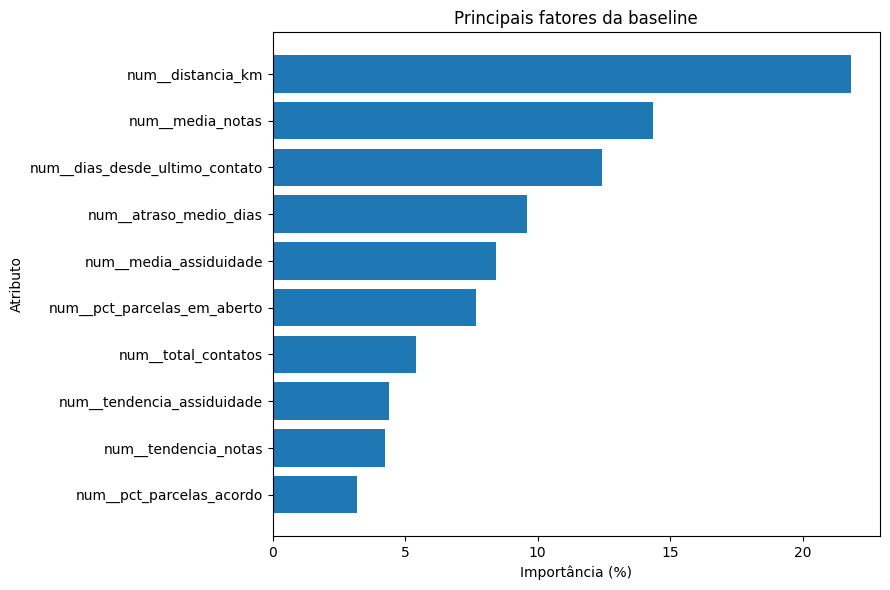

In [26]:
top_importancias = importancias.head(10).sort_values("Importancia_percentual")

plt.figure(figsize=(9, 6))
plt.barh(
    top_importancias["Atributo"],
    top_importancias["Importancia_percentual"]
)
plt.xlabel("Importância (%)")
plt.ylabel("Atributo")
plt.title("Principais fatores da baseline")
plt.tight_layout()
plt.show()

## 15. Resumo para o Relatório Técnico

Depois de executar todas as células, esta seção reúne os principais números que poderão ser utilizados no relatório e no Model Card.

In [27]:
resumo_entrega = {
    "Registros_base_original": len(df),
    "Alunos_unicos_base_original": df["ID_ALUNO"].nunique(),
    "Registros_base_preparada": len(dados),
    "Quantidade_features": len(features_selecionadas),
    "Modelo": "RandomForestClassifier",
    "Acuracia_percentual": round(accuracy_score(y_test, y_pred) * 100, 2),
    "Precisao_percentual": round(precision_score(y_test, y_pred, zero_division=0) * 100, 2),
    "Recall_percentual": round(recall_score(y_test, y_pred, zero_division=0) * 100, 2),
    "F1_percentual": round(f1_score(y_test, y_pred, zero_division=0) * 100, 2),
    "Limite_verde": f"score < {LIMITE_AMARELO}",
    "Limite_amarelo": f"{LIMITE_AMARELO} <= score < {LIMITE_VERMELHO}",
    "Limite_vermelho": f"score >= {LIMITE_VERMELHO}"
}

display(pd.DataFrame(
    resumo_entrega.items(),
    columns=["Item", "Resultado"]
))

,Item,Resultado
0,Registros_base_original,12846
1,Alunos_unicos_base_original,12839
2,Registros_base_preparada,12839
3,Quantidade_features,14
4,Modelo,RandomForestClassifier
5,Acuracia_percentual,80.61
6,Precisao_percentual,50.66
7,Recall_percentual,38.37
8,F1_percentual,43.67
9,Limite_verde,score < 30


## Evidências complementares para a Entrega

As células a seguir apresentam visualizações e tabelas resumidas que facilitam a interpretação da baseline e documentam os resultados utilizados no Relatório Técnico.

### Distribuição da variável-alvo

/tmp/ipykernel_1092/4115530810.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nao_evadiu = distribuicao.get(False, distribuicao.get(0, 0))
/tmp/ipykernel_1092/4115530810.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  evadiu = distribuicao.get(True, distribuicao.get(1, 0))


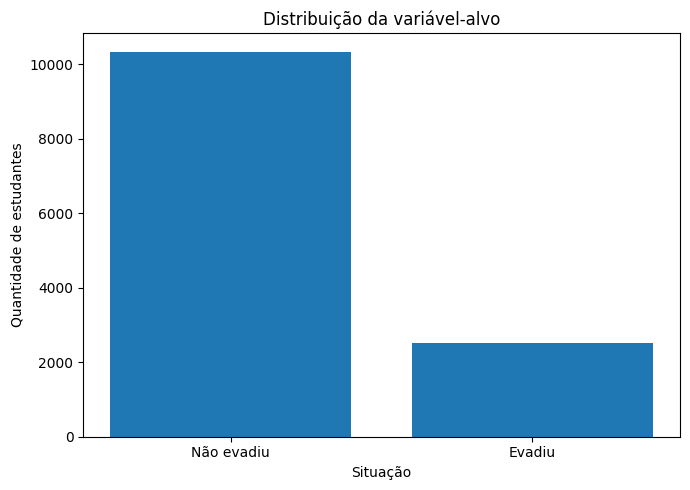

In [28]:
distribuicao = df["evadiu"].value_counts()
nao_evadiu = distribuicao.get(False, distribuicao.get(0, 0))
evadiu = distribuicao.get(True, distribuicao.get(1, 0))

plt.figure(figsize=(7, 5))
plt.bar(["Não evadiu", "Evadiu"], [nao_evadiu, evadiu])
plt.title("Distribuição da variável-alvo")
plt.ylabel("Quantidade de estudantes")
plt.xlabel("Situação")
plt.tight_layout()
plt.show()

### Resumo da qualidade dos dados

In [29]:
resumo_qualidade = pd.DataFrame({
    "Indicador": [
        "Registros originais",
        "Alunos distintos",
        "IDs duplicados",
        "Colunas com valores ausentes",
        "Total de valores ausentes"
    ],
    "Resultado": [
        len(df),
        df["ID_ALUNO"].nunique(),
        df["ID_ALUNO"].duplicated().sum(),
        (df.isna().sum() > 0).sum(),
        df.isna().sum().sum()
    ]
})
display(resumo_qualidade)

,Indicador,Resultado
0,Registros originais,12846
1,Alunos distintos,12839
2,IDs duplicados,7
3,Colunas com valores ausentes,1
4,Total de valores ausentes,87


### Comparação antes e depois da preparação

In [30]:
comparacao_preparacao = pd.DataFrame({
    "Etapa": ["Base original", "Base após preparação"],
    "Registros": [len(df), len(dados)],
    "Alunos distintos": [df["ID_ALUNO"].nunique(), dados["ID_ALUNO"].nunique()]
})
display(comparacao_preparacao)

,Etapa,Registros,Alunos distintos
0,Base original,12846,12839
1,Base após preparação,12839,12839


### Visualização das métricas

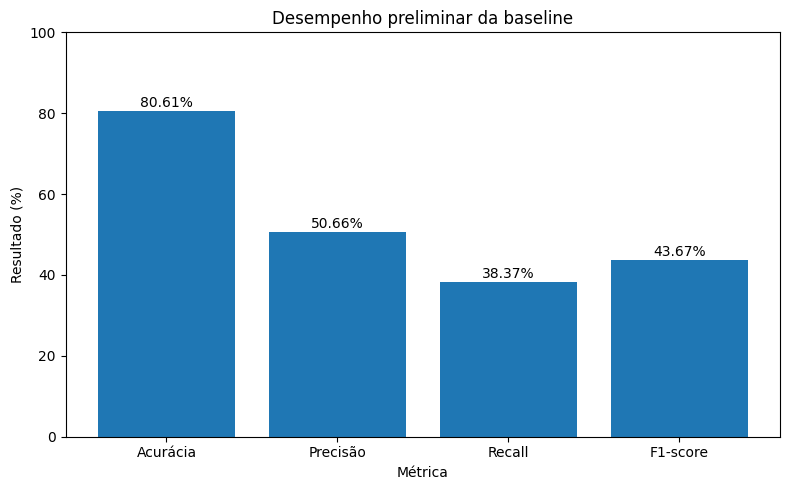

In [31]:
plt.figure(figsize=(8, 5))
plt.bar(metricas["Métrica"], metricas["Resultado"])
plt.title("Desempenho preliminar da baseline")
plt.ylabel("Resultado (%)")
plt.xlabel("Métrica")
plt.ylim(0, 100)
for i, valor in enumerate(metricas["Resultado"]):
    plt.text(i, valor + 1, f"{valor:.2f}%", ha="center")
plt.tight_layout()
plt.show()

### Interpretação da matriz de confusão

In [32]:
tn, fp, fn, tp = matriz.ravel()
resumo_matriz = pd.DataFrame({
    "Resultado": [
        "Não evasões identificadas corretamente",
        "Não evasões classificadas como evasão",
        "Evasões não identificadas",
        "Evasões identificadas corretamente"
    ],
    "Quantidade": [tn, fp, fn, tp]
})
display(resumo_matriz)

,Resultado,Quantidade
0,Não evasões identificadas corretamente,1877
1,Não evasões classificadas como evasão,188
2,Evasões não identificadas,310
3,Evasões identificadas corretamente,193


### Resultado do Agente de Monitoramento

In [33]:
resultado_monitoramento = resultado_teste[[
    "ID_ALUNO", "probabilidade_evasao", "score_risco", "classificacao_risco"
]].copy().sort_values("score_risco", ascending=False)

display(resultado_monitoramento.head(20))

,ID_ALUNO,probabilidade_evasao,score_risco,classificacao_risco
3086,3314,0.990000,99.00,Vermelho
652,11579,0.990000,99.00,Vermelho
3204,7401,0.987348,98.73,Vermelho
2129,14123,0.975000,97.50,Vermelho
1399,3176,0.975000,97.50,Vermelho
972,13557,0.975000,97.50,Vermelho
6337,3437,0.975000,97.50,Vermelho
102,2386,0.970000,97.00,Vermelho
3676,11967,0.960000,96.00,Vermelho
2532,16977,0.960000,96.00,Vermelho


## Conclusão da Baseline

A primeira baseline do **SISA** utiliza informações acadêmicas, financeiras, de relacionamento e geográficas para estimar uma probabilidade de evasão. Essa probabilidade é convertida em um score de risco de 0 a 100 e em uma classificação inicial Verde, Amarelo ou Vermelho.

Os resultados são preliminares e devem ser analisados por meio de diferentes métricas, principalmente porque as classes de evasão e não evasão possuem distribuições diferentes. O score tem finalidade de apoio ao acompanhamento e não substitui a análise humana.

Nas próximas etapas, a baseline poderá ser aprimorada por meio da comparação com outros modelos, revisão dos limiares, melhoria da qualidade dos dados e ampliação da explicabilidade.